In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [9]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
random.seed(42) # NOTE: only set this when you want to RESET the module
master.baseline(baseline_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time


the mouse moved this far: 324.8378051033331
[[-72.11040188 316.73283626]]
[-56.39298929 292.17957642]
the mouse moved this far: 645.4915509755027
[[-93.12732954 638.73832113]]
[-274.02534067  513.50974569]
the mouse moved this far: 830.8038755403552
[[334.79828485 760.35859177]]
[314.94333827 694.93349265]
the mouse moved this far: 590.563512381621
[[249.7969485  535.13245713]]
[219.58865515 550.4473581 ]
the mouse moved this far: 305.990081648238
[[223.24507229 209.26434901]]
[170.35891087 170.63596629]
the mouse moved this far: 695.1659687110055
[[618.37083717 317.60546561]]
[606.39570539 355.3511493 ]
the mouse moved this far: 612.8661508425307
[[-214.45005275 -574.12201989]]
[-254.348214   -681.34016628]
the mouse moved this far: 1032.6281339507282
[[343.57996188 973.79344464]]
[ 535.71181927 1284.75723179]
the mouse moved this far: 372.04076090991634
[[187.47003748 321.35543068]]
[148.91207816 249.77346825]
the mouse moved this far: 423.6262484642674
[[379.17139363 188.91334691]]


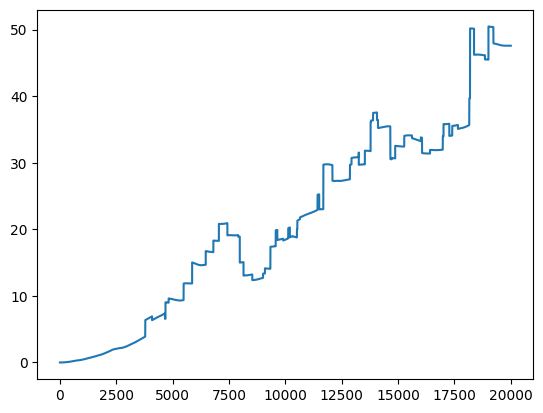

In [5]:
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)

plt.plot(x,y)
plt.show()

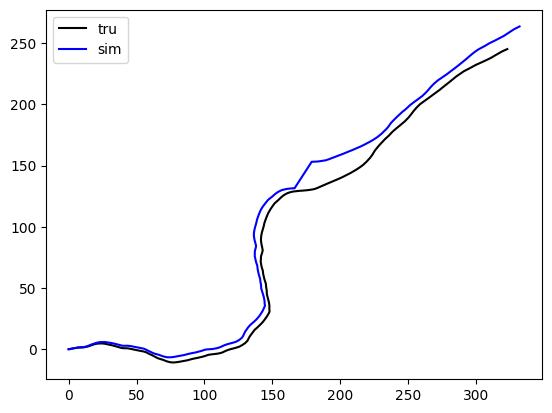

In [6]:
#plot true path vs sim path over time

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])



In [ ]:
#simulation time trial constants
simlen_trial_num = 3
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 197.0477825783775
[[145.71912774 132.64148835]]
[141.89377574 136.35990976]
the mouse moved this far: 311.8863220765836
[[309.28626762  40.18808979]]
[316.41862084  38.09314418]
the mouse moved this far: 101.00613397062313
[[81.68141052 59.41705374]]
[81.42325972 72.17259731]
the mouse moved this far: 1104.542938877463
[[726.02047797 832.41177875]]
[622.04474855 873.54650317]
the mouse moved this far: 229.38040333871317
[[211.85211202  87.94345951]]
[201.75804699  89.06504353]
the mouse moved this far: 825.2953834822194
[[ 45.38571275 824.04648356]]
[  3.58182112 786.72751176]
the mouse moved this far: 841.4736273706336
[[-59.716998   839.35197963]]
[ 54.92756146 723.65090533]
the mouse moved this far: 786.1792807582957
[[ 729.20861123 -293.8242039 ]]
[ 871.97055974 -274.7818193 ]
the mouse moved this far: 1228.2276770930105
[[871.2125946  865.75507032]]
[780.5669415  738.68389441]
the mouse moved this far: 798.8605059247685
[[ 175.63125347 -779.31493681]]
[ 1

In [12]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


In [ ]:
"""indira ... if you want can you make BAR charts of 
sim_trial_final_drifts, sim_trial_mean_errors,sim_trial_rmses
 (theres like 10 bars) 
x goes from simlen = 10000 to 100000 
y is the error 
"""

In [ ]:
# module number trial . keep range the same from 25 cm to 22.6m
module_num_trial_num = 3
module_num_iters = range(5,14)
module_num_spacings = [np.power(2266./25., (1/i)) for i in module_num_iters]
module_num_len = len(module_num_iters)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

#running trials!
module_num_final_drifts = np.zeros((module_num_len,module_num_trial_num))
module_num_mean_errors = np.zeros((module_num_len,module_num_trial_num))
module_num_rmses = np.zeros((module_num_len,module_num_trial_num))
module_num_errors_over_time = [] #NOT a numpy array. its a 3d one, len x trial_num x floor(simlen/errorfreq)

for i in range(module_num_len):
    master.baseline(module_num_len, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=module_num_iters[i], spacing_min=25,spacing = module_num_spacings[i])
    module_num_final_drifts[i] = master.all_final_drift
    module_num_mean_errors[i] = master.all_mean_error
    module_num_rmses[i] = master.all_rmse
    module_num_errors_over_time.append(master.all_error_over_time)

In [ ]:
"""tristan ... if you want can you make BAR charts of 
module_num_final_drifts, module_num_mean_errors, module_num_rmses
 (theres like 9 bars) 
x goes from 5 to 13
y is the error 
"""

In [ ]:
# module spacing trial..... do tmrw sophie
